In [ ]:
import pandas as pd
from modelens import ClassificationAnalyzer, classification_models

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [ ]:
raw_data = pd.read_csv("dataset.csv")

df = raw_data.copy()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.head()

In [ ]:
analyzer = ClassificationAnalyzer(df, target="Outcome")

#### 1 - EDA + ETL

In [ ]:
# Check Invalid Data
analyzer.info()

In [ ]:
analyzer.reinit(df=df, target="Outcome")

In [ ]:
df.head()

#### 2 - Comparing Models

In [ ]:
target = "Outcome"
X = df.drop(columns=[target])
y = df[target]
features = df.columns.drop(target)

In [ ]:
analyzer.correlation()

In [ ]:
analyzer.vif(features=features)

In [ ]:
analyzer.permutation_importance()

In [ ]:
models = classification_models()

analyzer.compare_models(
    models=models,
    features=features,
    export_html=True,
    file_name="01-base-model-comparing",
)
# selected_model = XGBoost

In [ ]:
from xgboost import XGBClassifier

selected_model = XGBClassifier(random_state=42)
# analyzer.evaluate_single_feature_removal(
#     model=model,
#     features=features,
#     export_html=True,
#     file_name="xgboost",
# )
# Remove Features = BMI
removed_features = ["BMI"]

In [ ]:

optimized_features = features.drop(removed_features)
analyzer.compare_feature_sets(
    model=selected_model,
    feature_sets={
        "All Features": features,
        "Optimized Features": optimized_features,
    },
)

----------
CatBoost
----------


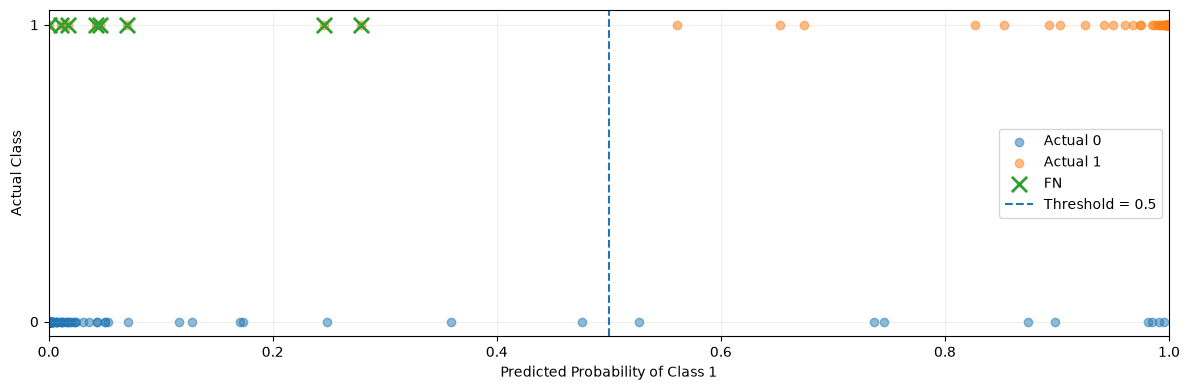

In [45]:
models = classification_models(smodels=["CatBoost"])
for name, model in models.items():
    print("-" * 10)
    print(name)
    print("-" * 10)
    analyzer.analyze_prediction_group(model=selected_model, features=features)

In [56]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

model = selected_model

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

cm_df

,Predicted 0,Predicted 1
Actual 0,91,9
Actual 1,8,46
